In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# =============================================
# IMPORTS
# =============================================
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from scipy.ndimage import gaussian_filter
import heapq

In [ ]:
# =============================================
# CONFIG — UPDATE THESE PATHS
# =============================================
MODEL_PATH = "/content/drive/MyDrive/final output multicamera/best_mobilenetv2 (4).keras"       # your downloaded model
IMAGE_PATH = "/content/drive/MyDrive/ASE Project/train data image.jpg"          # your test image

PATCH_SIZE  = 128
IMG_SIZE    = 128                            # new model uses 128 not 224
ALPHA       = 0.6                            # safety vs navigability weight

CLASS_NAMES = {
    0: "Bedrock",
    1: "Rocks",
    2: "Sand",
    3: "Pebbles"
}

In [ ]:
# =============================================
# SAFETY & NAVIGABILITY WEIGHTS
# =============================================
safety_weights = {
    0: 0.3,    # Bedrock → low safety
    1: 0.1,    # Rocks → very unsafe
    2: 0.9,    # Sand → very safe
    3: 0.7,    # Pebbles → moderate
}

navigability_weights = {
    0: 0.8,    # Bedrock → easy
    1: 0.5,    # Rocks → moderate
    2: 0.1,    # Sand → hard
    3: 0.9,    # Pebbles → easy
}


In [ ]:
# =============================================
# FOCAL LOSS (needed to load model)
# =============================================
def sparse_categorical_focal_loss(y_true, y_pred, gamma=2.0):
    NUM_CLASSES = 4
    y_true      = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    y_pred      = tf.cast(y_pred, tf.float32)
    xent_loss   = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=y_true,
        logits=tf.math.log(y_pred + 1e-7)
    )
    true_probs   = tf.gather(
        tf.reshape(y_pred, [-1, NUM_CLASSES]),
        y_true, batch_dims=1
    )
    focal_weight = tf.pow(1.0 - true_probs, gamma)
    return tf.reduce_mean(focal_weight * xent_loss)


In [ ]:
# =============================================
# LOAD MODEL
# =============================================
model = load_model(
    MODEL_PATH,
    custom_objects={"sparse_categorical_focal_loss": sparse_categorical_focal_loss}
)
print("✅ Model loaded successfully!")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


✅ Model loaded successfully!
Model input shape: (None, 128, 128, 3)
Model output shape: (None, 4)


In [ ]:
# =============================================
# LOAD IMAGE
# =============================================
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print("Original image shape:", img_rgb.shape)


Original image shape: (900, 1200, 3)


In [ ]:
# =============================================
# EXTRACT PATCHES
# =============================================
def extract_patches(image, patch_size=128):
    patches   = []
    positions = []
    h, w, c   = image.shape
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size]
            if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
                patches.append(patch)
                positions.append((i, j))
    return np.array(patches), positions

patches, positions = extract_patches(img_rgb, patch_size=PATCH_SIZE)
print(f"Number of patches: {len(patches)}")


Number of patches: 63


In [ ]:
# =============================================
# PREPROCESS PATCHES
# =============================================
def preprocess_patches(patches, img_size=128):
    processed = []
    for patch in patches:
        patch = tf.convert_to_tensor(patch, dtype=tf.float32)
        patch = tf.image.resize(patch, (img_size, img_size))
        patch = preprocess_input(patch)
        processed.append(patch)
    return tf.stack(processed)

X_patches = preprocess_patches(patches, img_size=IMG_SIZE)
print("Processed patches shape:", X_patches.shape)

Processed patches shape: (63, 128, 128, 3)


In [ ]:
# =============================================
# PREDICT
# =============================================
pred_probs   = model.predict(X_patches, batch_size=32)
pred_classes = np.argmax(pred_probs, axis=1)
print("Predicted classes:", pred_classes[:])


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
Predicted classes: [1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 3 3 3 3 3 3 0 0 3 0 3 3 0 3 0 1 0 0 3
 3 3 3 3 3 3 3 3 3 3 3 3 0 3 3 3 3 0 0 0 0 3 3 3 3 3]


In [ ]:
# =============================================
# BUILD GRIDS
# =============================================
def build_terrain_grid(image_shape, patch_size, pred_classes):
    h, w, _ = image_shape
    rows     = h // patch_size
    cols     = w // patch_size
    grid     = pred_classes[:rows * cols].reshape(rows, cols)
    return grid

terrain_grid = build_terrain_grid(img_rgb.shape, PATCH_SIZE, pred_classes)
print("Terrain grid shape:", terrain_grid.shape)


Terrain grid shape: (7, 9)


In [ ]:
# =============================================
# SAFETY & NAVIGABILITY GRIDS (probability-weighted)
# =============================================
rows     = img_rgb.shape[0] // PATCH_SIZE
cols     = img_rgb.shape[1] // PATCH_SIZE
n_patches = rows * cols

safety_grid      = np.zeros((rows, cols))
navigability_grid = np.zeros((rows, cols))
cost_grid        = np.zeros((rows, cols))

for idx in range(n_patches):
    r    = idx // cols
    c    = idx % cols
    pred = pred_probs[idx]

    safety      = sum(pred[cls] * safety_weights[cls] for cls in range(4))
    navigability = sum(pred[cls] * navigability_weights[cls] for cls in range(4))
    combined    = ALPHA * safety + (1 - ALPHA) * navigability
    cost        = 1.0 - combined

    safety_grid[r, c]       = safety
    navigability_grid[r, c] = navigability
    cost_grid[r, c]         = cost

print("Cost grid shape:", cost_grid.shape)


Cost grid shape: (7, 9)


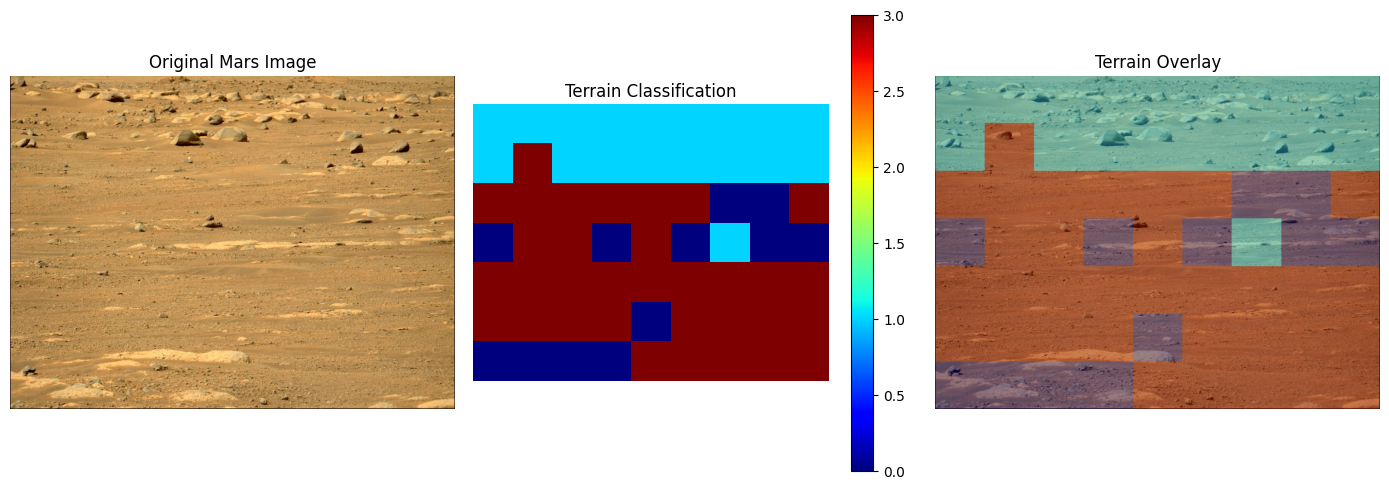

In [ ]:
# =============================================
# VISUALIZE TERRAIN HEATMAP
# =============================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Mars Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(terrain_grid, cmap="jet")
plt.title("Terrain Classification")
plt.colorbar()
plt.axis("off")

terrain_overlay = cv2.resize(
    terrain_grid.astype(np.float32),
    (img_rgb.shape[1], img_rgb.shape[0]),
    interpolation=cv2.INTER_NEAREST
)
plt.subplot(1, 3, 3)
plt.imshow(img_rgb)
plt.imshow(terrain_overlay, cmap="jet", alpha=0.4)
plt.title("Terrain Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


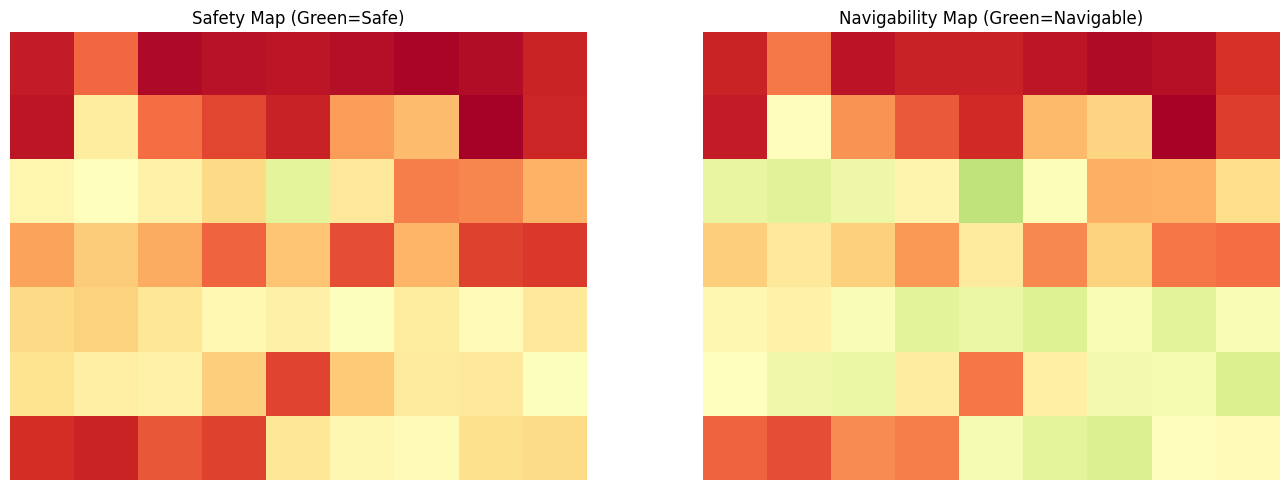

In [ ]:
# =============================================
# VISUALIZE SAFETY & NAVIGABILITY
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(safety_grid, cmap="RdYlGn", vmin=0, vmax=1)
axes[0].set_title("Safety Map (Green=Safe)")
axes[0].axis("off")

axes[1].imshow(navigability_grid, cmap="RdYlGn", vmin=0, vmax=1)
axes[1].set_title("Navigability Map (Green=Navigable)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# =============================================
# NAVIGABILITY REPORT
# =============================================
unique_classes, counts = np.unique(terrain_grid, return_counts=True)
total_patches = terrain_grid.size

print("\nTerrain-wise Navigability Report:\n")
for cls, count in zip(unique_classes, counts):
    terrain_name = CLASS_NAMES.get(int(cls), f"Class {cls}")
    nav_score    = navigability_weights.get(int(cls), 0)
    pct          = (count / total_patches) * 100
    print(f"Terrain: {terrain_name}")
    print(f"  Patch Count       : {count}")
    print(f"  % of Image        : {pct:.2f}%")
    print(f"  Navigability Score: {nav_score*100:.1f}%")
    print("-" * 40)

overall_nav = float(np.mean(navigability_grid) * 100)
print(f"\nOverall Navigability: {overall_nav:.2f}%")



Terrain-wise Navigability Report:

Terrain: Bedrock
  Patch Count       : 12
  % of Image        : 19.05%
  Navigability Score: 80.0%
----------------------------------------
Terrain: Rocks
  Patch Count       : 18
  % of Image        : 28.57%
  Navigability Score: 50.0%
----------------------------------------
Terrain: Pebbles
  Patch Count       : 33
  % of Image        : 52.38%
  Navigability Score: 90.0%
----------------------------------------

Overall Navigability: 35.59%



Path found: 9 steps


Planned Path Navigability: 43.93%


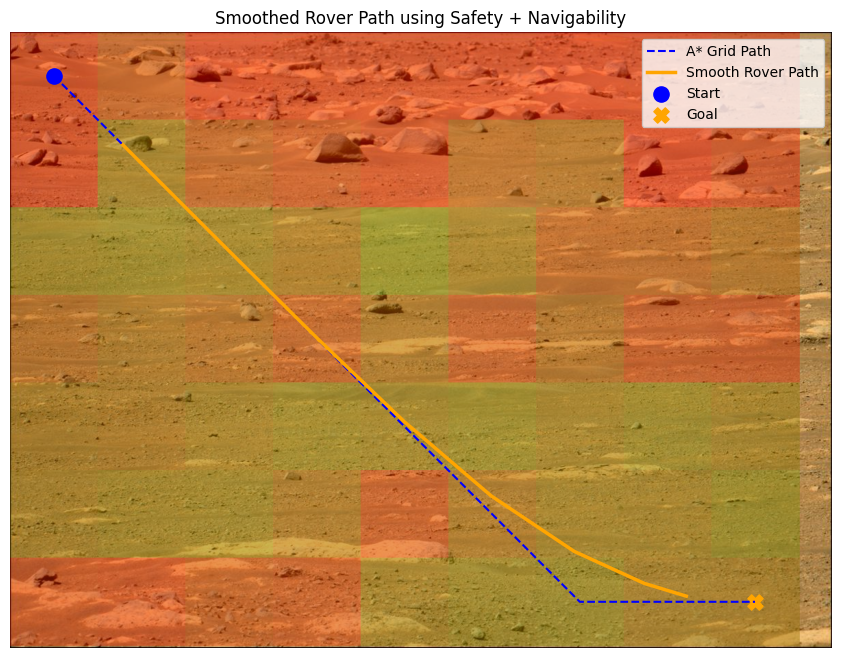


FINAL DECISION:
Decision: REROUTE
Reason  : Dangerous terrain ahead


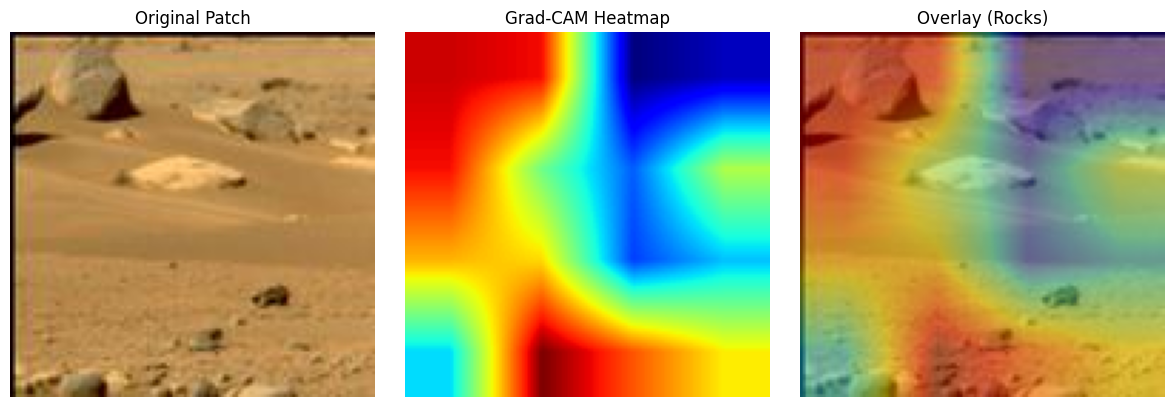


Predicted terrain for patch 0: Rocks
